<a href="https://colab.research.google.com/github/sevaradevoloper/machine-learning-class-work/blob/main/vdtushunrilgan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

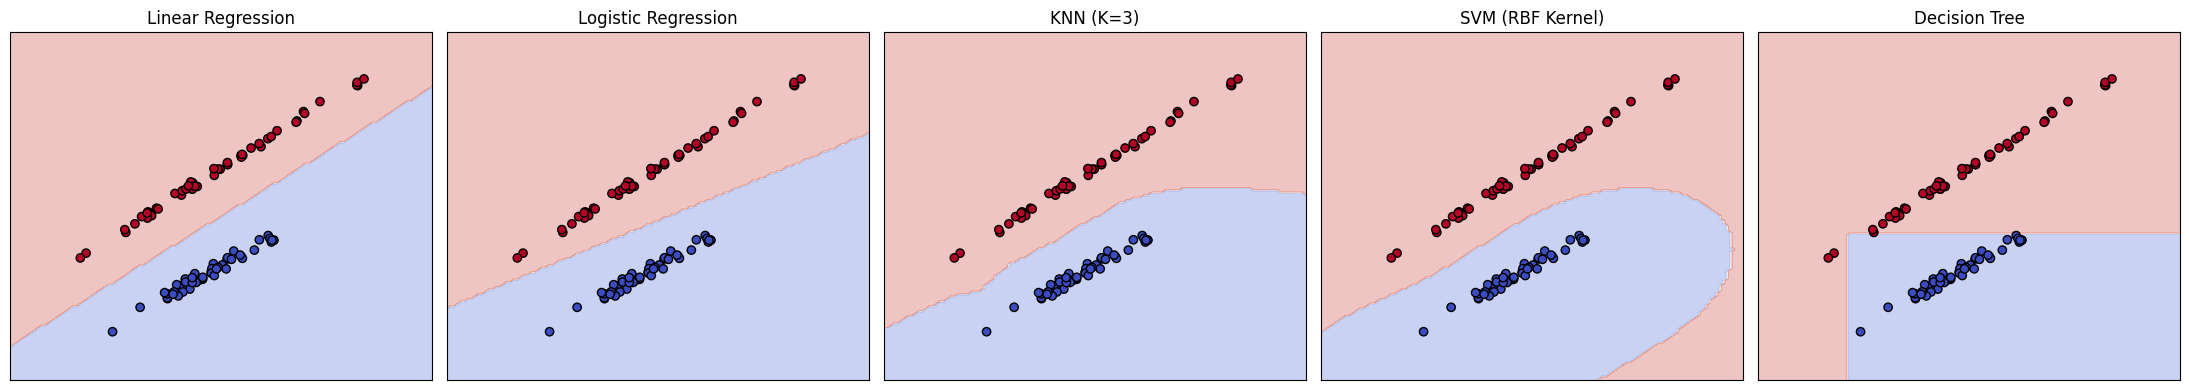

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# 1. Bitta umumiy dataset yaratamiz (nuqtalar o'zgarmaydi)
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# Modellar ro'yxati
models = {
    "Linear Regression": LinearRegression(),
    "Logistic Regression": LogisticRegression(),
    "KNN (K=3)": KNeighborsClassifier(n_neighbors=3),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True),
    "Decision Tree": DecisionTreeClassifier(max_depth=3)
}

# Meshgrid (Grafik fonini bo'yash uchun koordinatalar)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Plotlarni chiqarish
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X, y)

    # Prognoz va chegara tayyorlash
    if name == "Linear Regression":
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = (Z > 0.5).astype(int)
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)

    # Chegarani bo'yash va nuqtalarni qo'yish
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
!sudo apt-get update
!sudo apt-get install -y ffmpeg texlive-full libcairo2-dev libpango1.0-dev pkg-config
!pip install --upgrade pip
!pip install manim scikit-learn numpy xgboost

Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu noble InRelease
Hit:7 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:6.1.1-3ubuntu5).
texlive-full is already the newest version (2023.20240207-1).
libcairo2-dev is already the newest version (1.18.0

In [ ]:
!manim -pql --format=mp4 script.py MLAllModelsComplete


/usr/local/lib/python3.13/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.13/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):
Manim Community v0.21.0

Traceback (most recent call last):
  File "/usr/local/bin/manim", line 6, in <module>
    sys.exit(main())
             ~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/click/core.py", line 1631, in __call__
    return self.main(*args, **kwargs)
           ~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/di

In [ ]:
# ==============================================================================
# Google Colab uchun Manim + Scikit-Learn animatsiyasi
# Ishga tushirish uchun ushbu 2 ta katakni (cell) ketma-ket yurgizing:
#
# 1-KATAK (Kutubxonalarni o'rnatish):
# !sudo apt-get update && sudo apt-get install -y ffmpeg texlive-full
# !pip install manim scikit-learn numpy
#
# 2-KATAK (Kod va Videoni chiqarish):
# !manim -pql --format=mp4 script.py MLAllModelsComplete
# ==============================================================================

from manim import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

class MLAllModelsComplete(Scene):
    def construct(self):
        # 1. SARLAVHA VA SAHNA KO'RINISHI
        title = Text("ML Algoritmlari: Qaror Chegaralari va Konspekt", font_size=32, color=BLUE)
        title.to_edge(UP)
        self.play(Write(title))

        # Chap tarafda koordinata o'qi (Grafik)
        axes = Axes(
            x_range=[-3, 3, 1],
            y_range=[-3, 3, 1],
            x_length=5,
            y_length=5,
            axis_config={"color": GREY_C}
        ).to_edge(LEFT, buff=0.8).shift(DOWN * 0.3)

        # O'ng tarafda Konspekt oynasi (Matnlar uchun)
        notes_box = Rectangle(height=5.2, width=6.2, color=WHITE).to_edge(RIGHT, buff=0.5).shift(DOWN * 0.3)
        notes_title = Text("Mavzu konspekti", font_size=20, color=YELLOW).next_to(notes_box, UP, buff=0.1)

        self.play(Create(axes), Create(notes_box), Write(notes_title))

        # 2. BITTA UMUMIY MA'LUMOTLAR TO'PLAMI (DATASET)
        np.random.seed(42)
        X, y = make_classification(n_samples=40, n_features=2, n_redundant=0,
                                   n_clusters_per_class=1, random_state=42, class_sep=1.2)

        dots = VGroup()
        for point, label in zip(X, y):
            color = RED if label == 0 else BLUE
            dots.add(Dot(axes.c2p(point[0], point[1]), color=color, radius=0.07))

        self.play(FadeIn(dots))
        self.wait(1)

        # Helper funksiya: Scikit-Learn chegarasini Manim Contour (Egri chiziq) shakliga o'tkazish
        def get_decision_boundary(model, color):
            x_min, x_max = -3, 3
            y_min, y_max = -3, 3
            res = 50
            xs = np.linspace(x_min, x_max, res)
            ys = np.linspace(y_min, y_max, res)
            xx, yy = np.meshgrid(xs, ys)
            grid = np.c_[xx.ravel(), yy.ravel()]

            model.fit(X, y)
            if hasattr(model, "predict_proba"):
                preds = model.predict_proba(grid)[:, 1].reshape(res, res)
            else:
                preds = model.predict(grid).reshape(res, res)

            # Contouring orqali Z = 0.5 bo'lgan joyni to'g'ri chiziq/egri chiziq shaklida chizish
            contours = VGroup()
            for i in range(res - 1):
                for j in range(res - 1):
                    p = preds[i, j]
                    p_right = preds[i, j+1]
                    p_up = preds[i+1, j]

                    if (p - 0.5) * (p_right - 0.5) <= 0 or (p - 0.5) * (p_up - 0.5) <= 0:
                        pt = axes.c2p(xs[j], ys[i])
                        contours.add(Dot(pt, radius=0.03, color=color))
            return contours

        # 3. ALGORITMLAR RO'YXATI VA KONSPEKTLAR
        algorithms = [
            {
                "name": "1. Linear Regression",
                "model": LinearRegression(),
                "color": YELLOW,
                "note": [
                    "• Chiziqli regressiya modellashtiradi.",
                    "• Chegara: To'g'ri chiziq (0.5 bo'yicha).",
                    "• Nuqtalar orasidan eng maqbul",
                    "  to'g'ri chiziqni tortishga intiladi.",
                    "• Klassifikatsiya uchun doim ham",
                    "  ideal yechim berolmaydi."
                ]
            },
            {
                "name": "2. Logistic Regression",
                "model": LogisticRegression(),
                "color": GREEN,
                "note": [
                    "• S-simon Sigmoid funksiyasi.",
                    "• Ehtimollikni (0 va 1 oralig'ida)",
                    "  hisoblab beradi.",
                    "• Chegara: Bitta to'g'ri chiziq.",
                    "• Chiziqli ajraladigan ma'lumotlarda",
                    "  juda tez va aniq ishlaydi."
                ]
            },
            {
                "name": "3. K-Nearest Neighbors (KNN)",
                "model": KNeighborsClassifier(n_neighbors=3),
                "color": PURPLE,
                "note": [
                    "• Masofaga tayanuvchi algoritm.",
                    "• K=3 eng yaqin qo'shni ovoziga",
                    "  qarab sinfni aniqlaydi.",
                    "• Chegara: Moslashuvchan va egri.",
                    "• Kichik ma'lumotlarda mos keladi,",
                    "  lekin katta hajmda sekinlashadi."
                ]
            },
            {
                "name": "4. Support Vector Machine (SVM)",
                "model": SVC(kernel='rbf', probability=True),
                "color": TEAL,
                "note": [
                    "• Eng xavfsiz ajratuvchi chegara.",
                    "• Nuqtalar orasidagi masofani",
                    "  (Margin) maksimal darajada ochadi.",
                    "• RBF Kernel orqali nodiziqli (egri)",
                    "  chegaralarni ham juda yaxshi chizadi."
                ]
            },
            {
                "name": "5. Decision Tree",
                "model": DecisionTreeClassifier(max_depth=3),
                "color": ORANGE,
                "note": [
                    "• Mantiqiy savollar berish orqali",
                    "  shaxobchalarga bo'ladi.",
                    "• Chegara: Zina-poya / Tik burchakli.",
                    "• Oson tushuniladi, lekin tezda",
                    "  Overfitting (o'ta moslashish)",
                    "  muammosiga uchraydi."
                ]
            },
            {
                "name": "6. Random Forest (Bagging)",
                "model": RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42),
                "color": RED_B,
                "note": [
                    "• Ko'plab Decision Tree'lar ansambli.",
                    "• Bagging: Daraxtlar parallel o'qitiladi.",
                    "• O'rtacha ovoz berish orqali",
                    "  daraxtlarning xatolari silliqlanadi.",
                    "• Overfitting'ga chidamli."
                ]
            },
            {
                "name": "7. XGBoost (Boosting)",
                "model": xgb.XGBClassifier(n_estimators=10, max_depth=2, learning_rate=0.2),
                "color": PINK,
                "note": [
                    "• Sequential (Ketma-ket) Boosting.",
                    "• Har bir yangi daraxt oldingisining",
                    "  xatolarini (Residuals) to'g'rilaydi.",
                    "• Gradient Descent orqali optimallashadi.",
                    "• Amaliyotda va musobaqalarda",
                    "  eng yuqori aniqlikni beradi."
                ]
            }
        ]

        # 4. ANIMATSIYA DAVLATI (SILSILASI)
        current_boundary = VGroup()
        current_text_group = VGroup()

        for algo in algorithms:
            # Algoritm nomini chiqarish
            algo_title = Text(algo["name"], font_size=20, color=algo["color"]).next_to(notes_box, UP, buff=0.1)

            # Konspekt matnini shakllantirish
            bullet_texts = VGroup()
            for line in algo["note"]:
                bullet_texts.add(Text(line, font_size=15, color=WHITE))
            bullet_texts.arrange(DOWN, aligned_edge=LEFT, buff=0.15)
            bullet_texts.move_to(notes_box.get_center())

            # Chegarani olish
            new_boundary = get_decision_boundary(algo["model"], algo["color"])

            # Animatsiya almashinuvi
            if len(current_text_group) == 0:
                self.play(
                    Transform(notes_title, algo_title),
                    FadeIn(bullet_texts),
                    Create(new_boundary),
                    run_time=1.5
                )
            else:
                self.play(
                    Transform(notes_title, algo_title),
                    ReplacementTransform(current_text_group, bullet_texts),
                    ReplacementTransform(current_boundary, new_boundary),
                    run_time=1.5
                )

            current_boundary = new_boundary
            current_text_group = bullet_texts
            self.wait(2.5)

        # Yakuniy tozalash
        self.play(
            FadeOut(dots), FadeOut(axes), FadeOut(notes_box),
            FadeOut(current_boundary), FadeOut(current_text_group),
            FadeOut(notes_title), FadeOut(title)
        )
        self.wait(1)

In [ ]:
# 1. Script faylini yaratamiz
with open("script.py", "w") as f:
    f.write('''
from manim import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

class MLAllModelsComplete(Scene):
    def construct(self):
        title = Text("ML Algoritmlari: Qaror Chegaralari va Konspekt", font_size=32, color=BLUE)
        title.to_edge(UP)
        self.play(Write(title))

        axes = Axes(
            x_range=[-3, 3, 1], y_range=[-3, 3, 1],
            x_length=5, y_length=5, axis_config={"color": GREY_C}
        ).to_edge(LEFT, buff=0.8).shift(DOWN * 0.3)

        notes_box = Rectangle(height=5.2, width=6.2, color=WHITE).to_edge(RIGHT, buff=0.5).shift(DOWN * 0.3)
        notes_title = Text("Mavzu konspekti", font_size=20, color=YELLOW).next_to(notes_box, UP, buff=0.1)
        self.play(Create(axes), Create(notes_box), Write(notes_title))

        np.random.seed(42)
        X, y = make_classification(n_samples=40, n_features=2, n_redundant=0,
                                   n_clusters_per_class=1, random_state=42, class_sep=1.2)

        dots = VGroup()
        for point, label in zip(X, y):
            color = RED if label == 0 else BLUE
            dots.add(Dot(axes.c2p(point[0], point[1]), color=color, radius=0.07))

        self.play(FadeIn(dots))
        self.wait(1)

        def get_decision_boundary(model, color):
            res = 40
            xs = np.linspace(-3, 3, res)
            ys = np.linspace(-3, 3, res)
            xx, yy = np.meshgrid(xs, ys)
            grid = np.c_[xx.ravel(), yy.ravel()]

            model.fit(X, y)
            if hasattr(model, "predict_proba"):
                preds = model.predict_proba(grid)[:, 1].reshape(res, res)
            else:
                preds = model.predict(grid).reshape(res, res)

            contours = VGroup()
            for i in range(res - 1):
                for j in range(res - 1):
                    p, p_right, p_up = preds[i, j], preds[i, j+1], preds[i+1, j]
                    if (p - 0.5) * (p_right - 0.5) <= 0 or (p - 0.5) * (p_up - 0.5) <= 0:
                        pt = axes.c2p(xs[j], ys[i])
                        contours.add(Dot(pt, radius=0.03, color=color))
            return contours

        algorithms = [
            {"name": "1. Linear Regression", "model": LinearRegression(), "color": YELLOW, "note": ["• Chiziqli regressiya.", "• Chegara: To'g'ri chiziq.", "• Nuqtalar orasidan eng maqbul", "  chiziq tortadi."]},
            {"name": "2. Logistic Regression", "model": LogisticRegression(), "color": GREEN, "note": ["• Sigmoid funksiyasi.", "• Ehtimollik hisoblaydi.", "• Chegara: Bitta to'g'ri chiziq."]},
            {"name": "3. K-Nearest Neighbors (KNN)", "model": KNeighborsClassifier(n_neighbors=3), "color": PURPLE, "note": ["• Masofaga tayanadi.", "• K=3 eng yaqin qo'shni.", "• Chegara: Moslashuvchan va egri."]},
            {"name": "4. Support Vector Machine (SVM)", "model": SVC(kernel='rbf', probability=True), "color": TEAL, "note": ["• Maksimal Margin masofasi.", "• Nodiziqli chegaralarni", "  RBF Kernel bilan chizadi."]},
            {"name": "5. Decision Tree", "model": DecisionTreeClassifier(max_depth=3), "color": ORANGE, "note": ["• Mantiqiy savollar zanjiri.", "• Chegara: Zina-poya simon.", "• Overfitting'ga moyil."]},
            {"name": "6. Random Forest (Bagging)", "model": RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42), "color": RED_B, "note": ["• Ko'plab daraxtlar ansambli.", "• Parallel o'qitiladi (Bagging).", "• Xatolarni silliqlaydi."]},
            {"name": "7. XGBoost (Boosting)", "model": xgb.XGBClassifier(n_estimators=10, max_depth=2, learning_rate=0.2), "color": PINK, "note": ["• Ketma-ket (Sequential) Boosting.", "• Qoldiqlarni (Residuals) tuzatadi.", "• Yuqori aniqlik beradi."]}
        ]

        current_boundary = VGroup()
        current_text_group = VGroup()

        for algo in algorithms:
            algo_title = Text(algo["name"], font_size=20, color=algo["color"]).next_to(notes_box, UP, buff=0.1)
            bullet_texts = VGroup(*[Text(l, font_size=15, color=WHITE) for l in algo["note"]]).arrange(DOWN, aligned_edge=LEFT, buff=0.15).move_to(notes_box.get_center())
            new_boundary = get_decision_boundary(algo["model"], algo["color"])

            if len(current_text_group) == 0:
                self.play(Transform(notes_title, algo_title), FadeIn(bullet_texts), Create(new_boundary), run_time=1.2)
            else:
                self.play(Transform(notes_title, algo_title), ReplacementTransform(current_text_group, bullet_texts), ReplacementTransform(current_boundary, new_boundary), run_time=1.2)

            current_boundary, current_text_group = new_boundary, bullet_texts
            self.wait(2)

        self.play(FadeOut(dots), FadeOut(axes), FadeOut(notes_box), FadeOut(current_boundary), FadeOut(current_text_group), FadeOut(notes_title), FadeOut(title))
''')

# 2. Videoga o'girish va Colab pleyerida chiqarish
!manim -pql --format=mp4 script.py MLAllModelsComplete

from IPython.display import HTML
from base64 import b64encode

# Tayyor video faylini topish va pleyerga o'tkazish
mp4 = open('media/videos/script/480p15/MLAllModelsComplete.mp4', 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width="700" height="400" controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

Manim Community v0.21.0

[09/17/26 16:40:17] INFO     NumExpr defaulting to 2 threads.       ]8;id=982392;file:///usr/local/lib/python3.13/dist-packages/numexpr/utils.py\utils.py]8;;\:]8;id=828669;file:///usr/local/lib/python3.13/dist-packages/numexpr/utils.py#164\164]8;;\
[09/17/26 16:40:19] INFO     Animation 0 : Partial      ]8;id=721540;file:///usr/local/lib/python3.13/dist-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=212888;file:///usr/local/lib/python3.13/dist-packages/manim/scene/scene_file_writer.py#192\192]8;;\
                             movie file written in                              
                             '/content/media/videos/scr                         
                             ipt/480p15/partial_movie_f                         
                             iles/MLAllModelsComplete/2                         
                             118183852_693801952_223132                         
                        

In [ ]:
# 1. Manim uchun yangilangan mukammal script faylini yaratamiz
with open("script.py", "w") as f:
    f.write('''
from manim import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

class MLAllModelsComplete(Scene):
    def construct(self):
        # Sarlavha
        title = Text("ML Algoritmlari: Qaror Chegaralari Evolyutsiyasi", font_size=28, color=BLUE)
        title.to_edge(UP, buff=0.3)
        self.play(Write(title))

        # Koordinata o'qlari (Grafik maydoni)
        axes = Axes(
            x_range=[-3, 3, 1], y_range=[-3, 3, 1],
            x_length=5.2, y_length=5.2, axis_config={"color": GREY_C}
        ).to_edge(LEFT, buff=0.6).shift(DOWN * 0.2)

        # O'ng tarafdagi konspekt ramkasi
        notes_box = Rectangle(height=5.4, width=6.5, color=WHITE, fill_color=BLACK, fill_opacity=0.5).to_edge(RIGHT, buff=0.4).shift(DOWN * 0.2)
        notes_header = Text("Algoritm konspekti", font_size=20, color=YELLOW).next_to(notes_box, UP, buff=0.1)
        self.play(Create(axes), Create(notes_box), Write(notes_header))

        # Bitta umumiy va o'zgarmas Dataset (Nuqtalar)
        np.random.seed(42)
        X, y = make_classification(n_samples=40, n_features=2, n_redundant=0,
                                   n_clusters_per_class=1, random_state=42, class_sep=1.2)

        dots = VGroup()
        for point, label in zip(X, y):
            color = RED if label == 0 else BLUE
            dots.add(Dot(axes.c2p(point[0], point[1]), color=color, radius=0.08))

        self.play(FadeIn(dots))
        self.wait(1)

        # Chegara va rangli sohalarni (Decision Regions) hisoblaydigan funksiya
        def get_decision_visuals(model, main_color):
            res = 35
            xs = np.linspace(-3, 3, res)
            ys = np.linspace(-3, 3, res)
            xx, yy = np.meshgrid(xs, ys)
            grid = np.c_[xx.ravel(), yy.ravel()]

            model.fit(X, y)
            if hasattr(model, "predict_proba"):
                preds = model.predict_proba(grid)[:, 1].reshape(res, res)
            else:
                preds = model.predict(grid).reshape(res, res)

            boundary_dots = VGroup()
            background_rects = VGroup()

            dx = (xs[1] - xs[0])
            dy = (ys[1] - ys[0])

            for i in range(res - 1):
                for j in range(res - 1):
                    p = preds[i, j]
                    # Rangli fon kvadratchalari
                    rect_color = BLUE if p >= 0.5 else RED
                    pt_center = axes.c2p(xs[j] + dx/2, ys[i] + dy/2)
                    rect = Square(side_length=0.15, color=rect_color, fill_color=rect_color, fill_opacity=0.15)
                    rect.move_to(pt_center)
                    rect.set_stroke(width=0)
                    background_rects.add(rect)

                    # Chegara nuqtalari
                    p_right = preds[i, j+1]
                    p_up = preds[i+1, j]
                    if (p - 0.5) * (p_right - 0.5) <= 0 or (p - 0.5) * (p_up - 0.5) <= 0:
                        pt = axes.c2p(xs[j], ys[i])
                        boundary_dots.add(Dot(pt, radius=0.04, color=main_color))

            return VGroup(background_rects, boundary_dots)

        # Algoritmlar va ularning tushunarli konspekti
        algorithms = [
            {
                "name": "1. Linear Regression",
                "model": LinearRegression(),
                "color": YELLOW,
                "note": [
                    "• Mantiq: Nuqtalar orasidan eng mos chiziq tortadi.",
                    "• Chegara: Mutlaq to'g'ri chiziq (Linear).",
                    "• Klassifikatsiya: 0.5 qiymat bo'yicha ajratadi.",
                    "• Muammo: Chetdagi nuqtalarga juda ta'sirchan."
                ]
            },
            {
                "name": "2. Logistic Regression",
                "model": LogisticRegression(),
                "color": GREEN,
                "note": [
                    "• Mantiq: Sigmoid funksiyasi orqali ehtimollik beradi.",
                    "• Chegara: Bitta to'g'ri chiziq (Linear Boundary).",
                    "• Xususiyati: 0 va 1 oralig'ida aniq ehtimollik hisoblaydi.",
                    "• Qo'llanilishi: Chiziqli ajraluvchi ma'lumotlarda tez."
                ]
            },
            {
                "name": "3. K-Nearest Neighbors (KNN)",
                "model": KNeighborsClassifier(n_neighbors=3),
                "color": PURPLE,
                "note": [
                    "• Mantiq: Eng yaqin K=3 ta qo'shnisiga qarab aniqlaydi.",
                    "• Chegara: Moslashuvchan, egri va murakkab.",
                    "• Afzalligi: Formulalarsiz, masofaga tayanadi.",
                    "• Kamchiligi: Katta ma'lumotlarda sekinlashadi."
                ]
            },
            {
                "name": "4. Support Vector Machine (SVM)",
                "model": SVC(kernel='rbf', probability=True),
                "color": TEAL,
                "note": [
                    "• Mantiq: Sinf orasidagi masofani (Margin) maksimal ochadi.",
                    "• Chegara: RBF Kernel orqali nodiziqli (egri) chizadi.",
                    "• Xususiyati: Eng xavfsiz va optimal chegara.",
                    "• Kuchli tarafi: Murakkab fazolarda ham aniq ishlaydi."
                ]
            },
            {
                "name": "5. Decision Tree",
                "model": DecisionTreeClassifier(max_depth=3),
                "color": ORANGE,
                "note": [
                    "• Mantiq: Ketma-ket mantiqiy savollar beradi.",
                    "• Chegara: Zina-poya simon (90 daraja tik bo'linish).",
                    "• Afzalligi: Inson mantiqiga juda yaqin va tushunarli.",
                    "• Kamchiligi: Tezda Overfitting (o'ta moslashish) bo'ladi."
                ]
            },
            {
                "name": "6. Random Forest (Bagging)",
                "model": RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42),
                "color": RED_B,
                "note": [
                    "• Mantiq: Ko'plab Decision Tree'lar ansambli.",
                    "• Ishlashi: Parallel o'qitiladi (Bagging).",
                    "• Chegara: Silliqlashtirilgan zina-poyasimon.",
                    "• Natija: Yagona daraxt xatolarini to'g'rilaydi."
                ]
            },
            {
                "name": "7. XGBoost (Boosting)",
                "model": xgb.XGBClassifier(n_estimators=10, max_depth=2, learning_rate=0.2),
                "color": PINK,
                "note": [
                    "• Mantiq: Ketma-ket (Sequential) Boosting.",
                    "• Ishlashi: Har yangi daraxt oldingisining Residuals",
                    "  (xatolari) ustida o'qitiladi.",
                    "• Chegara: Juda aniq va moslashuvchan.",
                    "• Natija: Amaliyotda eng yuqori aniqlik beradi."
                ]
            }
        ]

        current_visuals = VGroup()
        current_text_group = VGroup()

        for algo in algorithms:
            algo_title = Text(algo["name"], font_size=20, color=algo["color"]).next_to(notes_box, UP, buff=0.1)

            bullet_texts = VGroup()
            for line in algo["note"]:
                bullet_texts.add(Text(line, font_size=14, color=WHITE))
            bullet_texts.arrange(DOWN, aligned_edge=LEFT, buff=0.2).move_to(notes_box.get_center())

            new_visuals = get_decision_visuals(algo["model"], algo["color"])

            if len(current_text_group) == 0:
                self.play(
                    Transform(notes_header, algo_title),
                    FadeIn(bullet_texts),
                    FadeIn(new_visuals[0]), # Rangli fon
                    Create(new_visuals[1]), # Chegara nuqtalari
                    run_time=1.5
                )
            else:
                self.play(
                    Transform(notes_header, algo_title),
                    ReplacementTransform(current_text_group, bullet_texts),
                    ReplacementTransform(current_visuals[0], new_visuals[0]),
                    ReplacementTransform(current_visuals[1], new_visuals[1]),
                    run_time=1.5
                )

            current_visuals = new_visuals
            current_text_group = bullet_texts
            self.wait(3)

        self.play(
            FadeOut(dots), FadeOut(axes), FadeOut(notes_box),
            FadeOut(current_visuals), FadeOut(current_text_group),
            FadeOut(notes_header), FadeOut(title)
        )
''')

# 2. Videoga o'girish
!manim -pql --format=mp4 script.py MLAllModelsComplete

# 3. Videoni ekraningizda pleyer ko'rinishida chiqarish
from IPython.display import HTML
from base64 import b64encode

mp4 = open('media/videos/script/480p15/MLAllModelsComplete.mp4', 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width="750" height="420" controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

Manim Community v0.21.0

[09/17/26 16:48:44] INFO     NumExpr defaulting to 2 threads.       ]8;id=941837;file:///usr/local/lib/python3.13/dist-packages/numexpr/utils.py\utils.py]8;;\:]8;id=654965;file:///usr/local/lib/python3.13/dist-packages/numexpr/utils.py#164\164]8;;\
[09/17/26 16:48:46] INFO     Animation 0 : Partial      ]8;id=630344;file:///usr/local/lib/python3.13/dist-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=671798;file:///usr/local/lib/python3.13/dist-packages/manim/scene/scene_file_writer.py#192\192]8;;\
                             movie file written in                              
                             '/content/media/videos/scr                         
                             ipt/480p15/partial_movie_f                         
                             iles/MLAllModelsComplete/2                         
                             118183852_3050204262_22313                         
                        